In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🧠 Convolutional Neural Network (CNN)

### Overview

A Convolutional Neural Network (CNN) is implemented to perform multi-class network intrusion detection on the CICDDoS2019 dataset.

Although CNNs are widely used in image processing, they can also be applied to tabular cybersecurity data by treating each network flow feature as a one-dimensional sequence. Convolutional layers automatically learn local patterns and feature interactions that may be indicative of malicious network behavior.

### Model Architecture

The proposed CNN architecture consists of:

- An input layer receiving the preprocessed network traffic features.
- Three 1D convolutional layers for automatic feature extraction.
- Batch Normalization layers to stabilize and accelerate training.
- MaxPooling layers to reduce dimensionality and retain the most informative features.
- Dropout layers to reduce overfitting.
- Fully connected Dense layers for classification.
- A Softmax output layer for multi-class prediction across the seven attack categories.

### Input Shape

The input data are reshaped into a three-dimensional format required by Conv1D layers:

```text
(samples, features, channels)
```

where:

- samples = number of network flows
- features = number of selected network traffic attributes
- channels = 1

### Training Configuration

The model is trained using:

- Optimizer: Adam
- Loss Function: Sparse Categorical Crossentropy
- Evaluation Metric: Accuracy
- Batch Size: 64
- Maximum Epochs: 30

### Regularization Techniques

To improve generalization performance, the following techniques are employed:

- Batch Normalization
- Dropout Regularization
- Early Stopping
- Model Checkpointing
- Learning Rate Reduction on Plateau

### Objective

The objective of this CNN model is to automatically learn discriminative network traffic patterns and accurately classify benign traffic and multiple DDoS attack categories.

## 📚 1. Import Required Libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pickle
import joblib

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)

from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

## 💾 2. Load Preprocessed Datasets


In [17]:
X_train = np.load(
    '/content/drive/MyDrive/IDS_Project/data/X_train.npy'
)

y_train = np.load(
    '/content/drive/MyDrive/IDS_Project/data/y_train.npy'
)

X_test = np.load(
    '/content/drive/MyDrive/IDS_Project/data/X_test.npy'
)

y_test = np.load(
    '/content/drive/MyDrive/IDS_Project/data/y_test.npy'
)

In [18]:
)

label_encoder = joblib.load(
    '/content/drive/MyDrive/IDS_Project/data/label_encoder.pkl'
)

In [ ]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(136787, 27)
(136787,)
(40568, 27)
(40568,)


## 3. Reshape Features for CNN Input


In [19]:
X_train_cnn = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_cnn = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

(136787, 27, 1)
(40568, 27, 1)


## 🔀 4. Training and Validation Split

In [20]:
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(

    X_train_cnn,
    y_train,

    test_size=0.2,
    stratify=y_train,
    random_state=42

)

### CNN Architecture Implementation

In [36]:
K.clear_session()

In [37]:
model_cnn = Sequential([

    Input(shape=(27,1)),

    Conv1D(16, 3, activation='relu'),

    Conv1D(32, 3, activation='relu'),

    Conv1D(64, 3, activation='relu'),

    MaxPooling1D(2),

    Flatten(),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(7, activation='softmax')
])

In [38]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 25, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 23, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 21, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,319 (192.65 KB)

 Trainable params: 49,319 (192.65 KB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ 6. Model Compilation

In [40]:
model_cnn.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

## 📌 7. Training Strategy

In [41]:
# Early stopping
early_stop = EarlyStopping(

    monitor='val_loss',
    patience=5,
    restore_best_weights=True

)

# Save best model
checkpoint = ModelCheckpoint(

    filepath='best_cnn_model_7_classes.h5',

    monitor='val_accuracy',

    save_best_only=True,

    mode='max',

    verbose=1

)

### Model Training

In [42]:
history = model_cnn.fit(

    X_train_sub,
    y_train_sub,

    validation_data=(
        X_val_sub,
        y_val_sub
    ),

    epochs=30,

    batch_size=64,

    callbacks=[
        early_stop,
        checkpoint
    ],

    verbose=1

)

Epoch 1/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6677 - loss: 0.6928
Epoch 1: val_accuracy improved from None to 0.70952, saving model to best_cnn_model_7_classes.h5



Epoch 1: finished saving model to best_cnn_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.6919 - loss: 0.5795 - val_accuracy: 0.7095 - val_loss: 0.5196
Epoch 2/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7056 - loss: 0.5284
Epoch 2: val_accuracy improved from 0.70952 to 0.71241, saving model to best_cnn_model_7_classes.h5



Epoch 2: finished saving model to best_cnn_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7069 - loss: 0.5254 - val_accuracy: 0.7124 - val_loss: 0.5157
Epoch 3/30
1705/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7084 - loss: 0.5178
Epoch 3: val_accuracy improved from 0.71241 to 0.71244, saving model to best_cnn_model_7_classes.h5



Epoch 3: finished saving model to best_cnn_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7075 - loss: 0.5198 - val_accuracy: 0.7124 - val_loss: 0.5108
Epoch 4/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7107 - loss: 0.5184
Epoch 4: val_accuracy did not improve from 0.71244
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7110 - loss: 0.5164 - val_accuracy: 0.7103 - val_loss: 0.5111
Epoch 5/30
1706/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7106 - loss: 0.5125
Epoch 5: val_accuracy improved from 0.71244 to 0.71299, saving model to best_cnn_model_7_classes.h5



Epoch 5: finished saving model to best_cnn_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7105 - loss: 0.5137 - val_accuracy: 0.7130 - val_loss: 0.5065
Epoch 6/30
1707/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7092 - loss: 0.5125
Epoch 6: val_accuracy improved from 0.71299 to 0.71851, saving model to best_cnn_model_7_classes.h5



Epoch 6: finished saving model to best_cnn_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7104 - loss: 0.5121 - val_accuracy: 0.7185 - val_loss: 0.5071
Epoch 7/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7108 - loss: 0.5118
Epoch 7: val_accuracy improved from 0.71851 to 0.71884, saving model to best_cnn_model_7_classes.h5



Epoch 7: finished saving model to best_cnn_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7112 - loss: 0.5111 - val_accuracy: 0.7188 - val_loss: 0.5066
Epoch 8/30
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7131 - loss: 0.5072
Epoch 8: val_accuracy did not improve from 0.71884
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7116 - loss: 0.5087 - val_accuracy: 0.7152 - val_loss: 0.5055
Epoch 9/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7134 - loss: 0.5068
Epoch 9: val_accuracy improved from 0.71884 to 0.72056, saving model to best_cnn_model_7_classes.h5



Epoch 9: finished saving model to best_cnn_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7123 - loss: 0.5079 - val_accuracy: 0.7206 - val_loss: 0.5024
Epoch 10/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7104 - loss: 0.5059
Epoch 10: val_accuracy did not improve from 0.72056
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7122 - loss: 0.5059 - val_accuracy: 0.7153 - val_loss: 0.5013
Epoch 11/30
1704/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7155 - loss: 0.5046
Epoch 11: val_accuracy improved from 0.72056 to 0.72078, saving model to best_cnn_model_7_classes.h5



Epoch 11: finished saving model to best_cnn_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7145 - loss: 0.5050 - val_accuracy: 0.7208 - val_loss: 0.4988
Epoch 12/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7109 - loss: 0.5035
Epoch 12: val_accuracy did not improve from 0.72078
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7126 - loss: 0.5047 - val_accuracy: 0.7201 - val_loss: 0.5012
Epoch 13/30
1706/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7116 - loss: 0.5038
Epoch 13: val_accuracy did not improve from 0.72078
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7126 - loss: 0.5037 - val_accuracy: 0.7134 - val_loss: 0.5028
Epoch 14/30
1707/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7132 - loss: 0.5018
Epoch 14: val_accuracy did not improve from 0.72078
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7118 - loss: 0.5032 - val_accuracy: 0.7162 - val_loss: 0.4977
Epoch 15/30
1706/1710 ━━━━━━━

### Model Evaluation

In [43]:
test_loss, test_acc = model_cnn.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9068
Test Loss: 0.4617


## 🔮 Generating Predictions

In [ ]:
y_pred_probs = model_cnn.predict(X_test_cnn)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

1268/1268 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


## 10. Classification Performance

In [ ]:
class_names = label_encoder.classes_

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

       BENIGN       0.97      0.98      0.97     10873
   DrDoS_LDAP       0.77      0.94      0.85       978
  DrDoS_MSSQL       0.32      0.14      0.19      1860
DrDoS_NetBIOS       0.01      0.04      0.02       503
    DrDoS_UDP       1.00      0.90      0.94      8602
          Syn       1.00      1.00      1.00     17297
      UDP-lag       0.25      0.47      0.33       455

     accuracy                           0.91     40568
    macro avg       0.62      0.64      0.61     40568
 weighted avg       0.93      0.91      0.92     40568



### Confusion Matrix Analysis

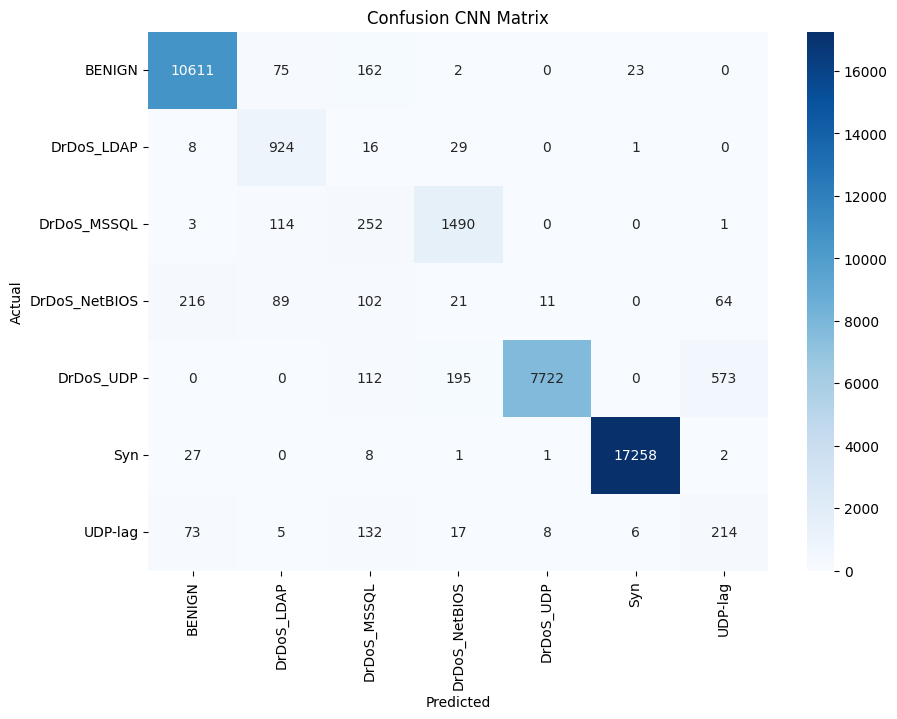

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion CNN Matrix")

plt.show()

### Training and Validation Curves

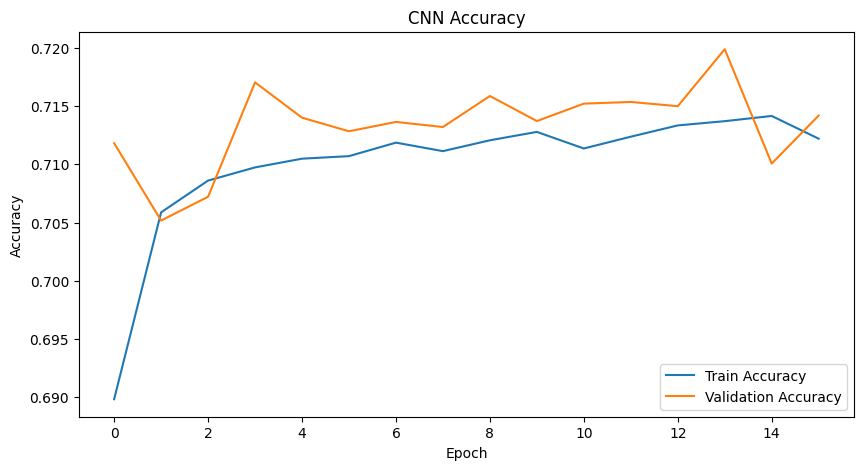

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

## Courbe Loss


In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid()

plt.show()


## 💾 Saving the Trained Model


## Saving history

In [ ]:
with open('CNN_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

## Saving metrics

In [ ]:
metrics = {
    "accuracy": test_acc,
    "loss": test_loss
}

with open('CNN_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

In [ ]:
np.save('CNN_pred.npy', y_pred)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     10873
           1       0.77      0.94      0.85       978
           2       0.32      0.14      0.19      1860
           3       0.01      0.04      0.02       503
           4       1.00      0.90      0.94      8602
           5       1.00      1.00      1.00     17297
           6       0.25      0.47      0.33       455

    accuracy                           0.91     40568
   macro avg       0.62      0.64      0.61     40568
weighted avg       0.93      0.91      0.92     40568

